<a href="https://colab.research.google.com/github/Korsah23/pneumniaMNIST/blob/main/pneumoniaMnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import torch
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn as nn
!pip install medmnist

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')




In [15]:
#reproducibility values

seed = 42
BATCH_SIZE = 10
input_size = 28
epochs = 15

torch.manual_seed(seed)
np.random.seed(seed)

In [16]:
#imort data source
import medmnist
from medmnist import PneumoniaMNIST

#initialise transform function
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])



#download training set
train_dataset = PneumoniaMNIST(
    split="train",
    transform = transform,
    download=True
)


#download validation swt
val_dataset = PneumoniaMNIST(
    split="val",
    transform = transform,
    download=True
)

#dwnload test set
test_dataset = PneumoniaMNIST(
    split="test",
    transform = transform,
    download=True
)

In [17]:
#create DATALOADER

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle = True
)

#print(train_loader.image)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle = False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle = False
)

images, labels = next(iter(train_loader))


In [18]:
#transfer learning
from torchvision import models
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

resnet_model = models.resnet18(weights=weights)
for param in resnet_model.parameters():
    param.requires_grad = False

for param in resnet_model.conv1.parameters():
    param.requires_grad = True

for param in resnet_model.fc.parameters():
    param.requires_grad = True

num_features = resnet_model.fc.in_features

resnet_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
resnet_model.maxpool = nn.Identity()
resnet_model.fc = nn.Linear(num_features, 2)
weights = ResNet18_Weights.DEFAULT
print(weights.transforms())
#print(resnet_model)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [19]:
import torch.nn as nn


#define model
class PneumoniaModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels=1,
                           out_channels=16,
                           kernel_size=3
                           )
    self.bn1 = nn.BatchNorm2d(16)
    self.ReLu = nn.ReLU()
    self.pool1 = nn.MaxPool2d(kernel_size=2)

    self.conv2 = nn.Conv2d(
        in_channels=16,
        out_channels=32,
        kernel_size=3
    )
    self.bn2 = nn.BatchNorm2d(32)
    self.pool2 = nn.MaxPool2d(kernel_size=2)

    self.conv3 = nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3
    )
    self.bn3 = nn.BatchNorm2d(64)
    self.pool3 = nn.MaxPool2d(kernel_size=2)

    self.drop = nn.Dropout(0.5)
    self.fc1 = nn.Linear(64, 32)
    self.fc2 = nn.Linear(32, 2)


#forward pass
  def forward(self,x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.ReLu(x)
    x = self.pool1(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.ReLu(x)
    x = self.pool2(x)

    x = self.conv3(x)
    x = self.bn3(x)
    x = self.ReLu(x)
    x = self.pool3(x)

   # x = self.pool(x)
    x = self.drop(x)
    x = torch.flatten(x, start_dim=1)

    x = self.fc1(x)
    x = self.fc2(x)
    return x


In [20]:
from torchsummary import summary
model = PneumoniaModel()
model = resnet_model
model.to(device)
#summary(model, (1,28,28))

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [21]:
from torch.optim import optimizer
import torch.optim as optim



criterion = nn.CrossEntropyLoss()

#define optimiser function
optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay=1e-4)


In [9]:
#train model now
#losses = []
train_losses = []
val_losses = []


for epoch in range(epochs):
  model.train()
  running_loss = 0.0

  for images, labels in train_loader:
    labels = labels.squeeze()
    y_pred = model(images)
    loss = criterion(y_pred, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    #running_loss /= len(train_loader)
  train_loss = running_loss / len(train_loader)
  train_losses.append(train_loss)



  model.eval()

  running_val_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():

      for images, labels in val_loader:

          labels = labels.squeeze()

          outputs = model(images)

          loss = criterion(outputs, labels)

          running_val_loss += loss.item()

          predictions = torch.argmax(
                outputs,
                dim=1
            )
          correct += (
                predictions == labels
            ).sum().item()

          total += labels.size(0)

      val_loss = running_val_loss / len(val_loader)

      val_accuracy = correct / total

      val_losses.append(val_loss)


  print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )



Epoch 1/15 | Train Loss: 0.3535 | Val Loss: 0.3218 | Val Acc: 0.8531
Epoch 2/15 | Train Loss: 0.2645 | Val Loss: 0.2595 | Val Acc: 0.8912
Epoch 3/15 | Train Loss: 0.2407 | Val Loss: 0.2434 | Val Acc: 0.9008
Epoch 4/15 | Train Loss: 0.2469 | Val Loss: 0.2186 | Val Acc: 0.9218
Epoch 5/15 | Train Loss: 0.2521 | Val Loss: 0.2226 | Val Acc: 0.9103
Epoch 6/15 | Train Loss: 0.2303 | Val Loss: 0.2123 | Val Acc: 0.9122
Epoch 7/15 | Train Loss: 0.2445 | Val Loss: 0.2034 | Val Acc: 0.9237
Epoch 8/15 | Train Loss: 0.2263 | Val Loss: 0.1941 | Val Acc: 0.9198
Epoch 9/15 | Train Loss: 0.2338 | Val Loss: 0.2053 | Val Acc: 0.9256
Epoch 10/15 | Train Loss: 0.2310 | Val Loss: 0.2838 | Val Acc: 0.8874
Epoch 11/15 | Train Loss: 0.2382 | Val Loss: 0.2017 | Val Acc: 0.9141
Epoch 12/15 | Train Loss: 0.2312 | Val Loss: 0.2222 | Val Acc: 0.9179
Epoch 13/15 | Train Loss: 0.2248 | Val Loss: 0.2709 | Val Acc: 0.8950
Epoch 14/15 | Train Loss: 0.2198 | Val Loss: 0.1938 | Val Acc: 0.9218
Epoch 15/15 | Train Loss: 0.2

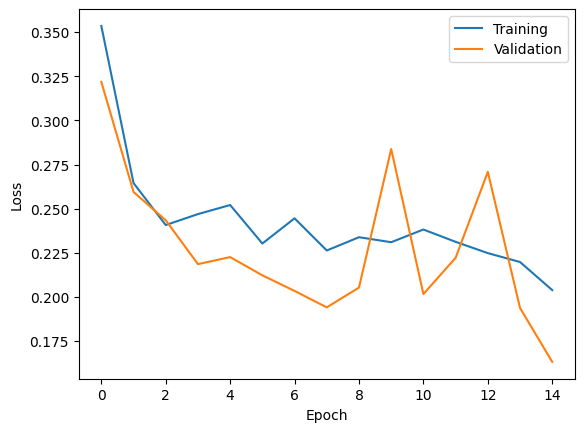

In [10]:
plt.plot(train_losses, label="Training")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        labels = labels.squeeze()

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[118  17]
 [ 17 372]]


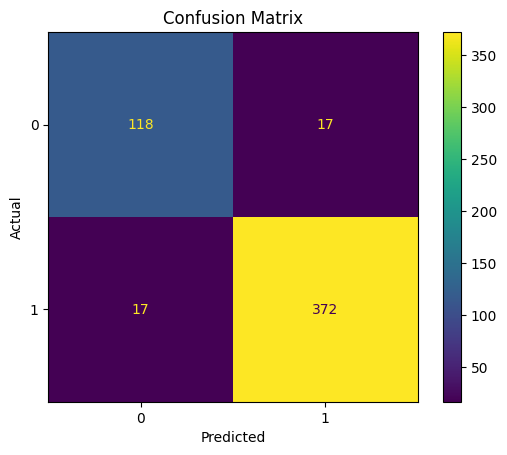

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [13]:
print(np.unique(all_labels, return_counts=True))
print(np.unique(all_predictions, return_counts=True))

(array([0, 1]), array([135, 389]))
(array([0, 1]), array([135, 389]))


In [14]:
torch.save(model.state_dict(), "pneumonia_model.pth")
print("Saved pneumonia_model.pth")


Saved pneumonia_model.pth
